# Exploring convutional layers through data

## Nicolás Toro Criollo

---

### Introduction

This notebook compares a dense (fully connected) baseline against a convolutional neural network (CNN) for classifying a 4-class vehicle subset of CIFAR-10 (airplane, automobile, ship, truck). The CNN reached 87.30% test accuracy, showing that convolutional layers are more efficient at learning from image data due to their inductive bias (locality and weight sharing). A controlled experiment removing pooling from the CNN confirmed this: without pooling, accuracy dropped to 80.18% and the model overfit severely, despite having more parameters. The notebook also documents an attempt to train and deploy the model on Amazon SageMaker, which was affected by several network restrictions in the university-provided AWS environment (detailed in Section 7.5).

### 0. Setup and imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

# De una vez fijamos la semilla para que los resultados sean comparables
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Dataset Selection and Justification

For this assignment, I selected **CIFAR-10**, restricted to a vehicle-related subset of 4 classes: airplane, automobile, ship, and truck.

CIFAR-10 is a good fit for a convolutional architecture for a few reasons:

- It is image-based (32x32 RGB, 3 channels), which satisfies the assignment's dataset constraints.
- It is small enough to fit in memory on a laptop or a standard cloud notebook instance, so training does not require special hardware.
- Compared to datasets like MNIST, CIFAR-10 images have real backgrounds, variable lighting, and different object poses.
- These classes still have enough visual diversity (different shapes, backgrounds, and viewpoints).
- At the same time, they share some common local patterns (edges, wheels, hulls, wings, metallic textures) that a convolutional layer is specifically designed to detect through local receptive fields and weight sharing.

## 2. EDA (Exploraory Data Analysis)

Anlyzind the dataset, we can see that it gice us 10 classes, but we will only use 4 of them, which are the ones related to vehicles. The classes are: airplane, automobile, ship, and truck. We filtered the dataset to only use these classes.

The original dataset labels for these classes are not consecutive, so we will remap them to a new set of labels: 0 for airplane, 1 for automobile, 2 for ship, and 3 for truck. This is necessary because the output layer of the models will have 4 units, one per selected class.

### Loading the dataset and remapping the labels

In [2]:
# Indices de las clases de CIFAR-10 (según lo definido por el dataset) que corresponden a vehículos
VEHICLE_CLASSES = {0: "airplane", 1: "automobile", 8: "ship", 9: "truck"}
vehicle_ids_original = sorted(VEHICLE_CLASSES.keys())  # [0, 1, 8, 9]


# Cargar el dataset completo de CIFAR-10
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

# Para facilitar el filtrado, aplanamos y_train_full/y_test_full de (N, 1) a (N,)
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Se construye una máscara para mantener solo las clases de vehículos
train_mask = np.isin(y_train_full, vehicle_ids_original)
test_mask = np.isin(y_test_full, vehicle_ids_original)

X_train_raw = X_train_full[train_mask]
y_train_raw = y_train_full[train_mask]
X_test_raw = X_test_full[test_mask]
y_test_raw = y_test_full[test_mask]

# Remapear las etiquetas originales {0,1,8,9} a etiquetas consecutivas {0,1,2,3}
label_map = {orig: new for new, orig in enumerate(vehicle_ids_original)}
class_names = [VEHICLE_CLASSES[orig] for orig in vehicle_ids_original]

y_train = np.array([label_map[label] for label in y_train_raw])
y_test = np.array([label_map[label] for label in y_test_raw])

print("X_train_raw shape:", X_train_raw.shape)
print("y_train shape:", y_train.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_test shape:", y_test.shape)
print("Class names (index order):", class_names)

X_train_raw shape: (20000, 32, 32, 3)
y_train shape: (20000,)
X_test_raw shape: (4000, 32, 32, 3)
y_test shape: (4000,)
Class names (index order): ['airplane', 'automobile', 'ship', 'truck']


### Dataset size and class distribution
Before training the model, it is very importatn to check the classes are balanced. If one class has many samples than the others, the model could reach a high accuracy just by favoring that class, without learning useful patterns.

Total training samples: 20000
Total test samples: 4000

 class_id class_name  count split
        0   airplane   5000 train
        1 automobile   5000 train
        2       ship   5000 train
        3      truck   5000 train

 class_id class_name  count split
        0   airplane   1000  test
        1 automobile   1000  test
        2       ship   1000  test
        3      truck   1000  test


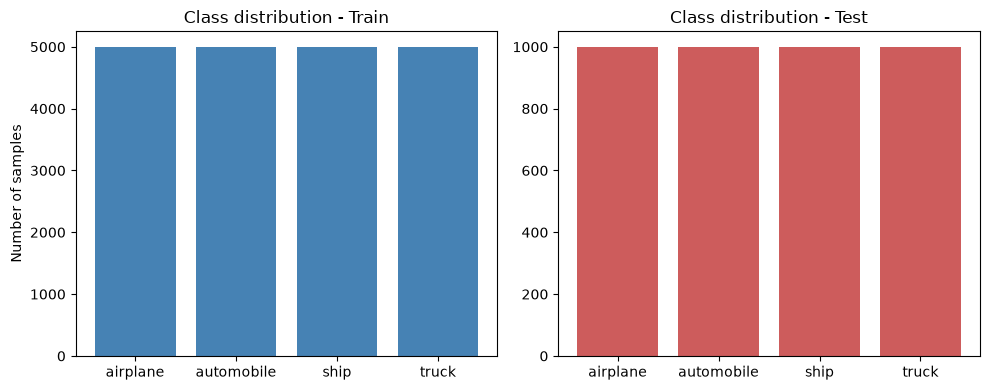

In [3]:
import pandas as pd

def class_distribution(y, class_names, split_name):
    counts = pd.Series(y).value_counts().sort_index()
    df = pd.DataFrame({
        "class_id": counts.index,
        "class_name": [class_names[i] for i in counts.index],
        "count": counts.values
    })
    df["split"] = split_name
    return df

train_dist = class_distribution(y_train, class_names, "train")
test_dist = class_distribution(y_test, class_names, "test")

print("Total training samples:", len(y_train))
print("Total test samples:", len(y_test))
print()
print(train_dist.to_string(index=False))
print()
print(test_dist.to_string(index=False))

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(train_dist["class_name"], train_dist["count"], color="steelblue")
axes[0].set_title("Class distribution - Train")
axes[0].set_ylabel("Number of samples")

axes[1].bar(test_dist["class_name"], test_dist["count"], color="indianred")
axes[1].set_title("Class distribution - Test")

plt.tight_layout()
plt.show()

### Image dimensions and channels
Each image in te dataset is expected to be 32x32 pixels with 3 colors channels (RGB). This is important to check, because the input layer of the models will expect this shape. Besides, we are going to check the raw pixel value range.

In [4]:
sample_shape = X_train_raw[0].shape
height, width, channels = sample_shape

print("Sample image shape:", sample_shape)
print("Height:", height)
print("Width:", width)
print("Channels:", channels)

all_same_shape = all(img.shape == sample_shape for img in X_train_raw) and all(img.shape == sample_shape for img in X_test_raw)
print("All images have the same shape:", all_same_shape)

Sample image shape: (32, 32, 3)
Height: 32
Width: 32
Channels: 3
All images have the same shape: True


### Visualization

Creating a CCN model, looking at real examples before training is important to understand the data and the problem we are trying to solve. We will visualize a few samples from each class, along with their labels.

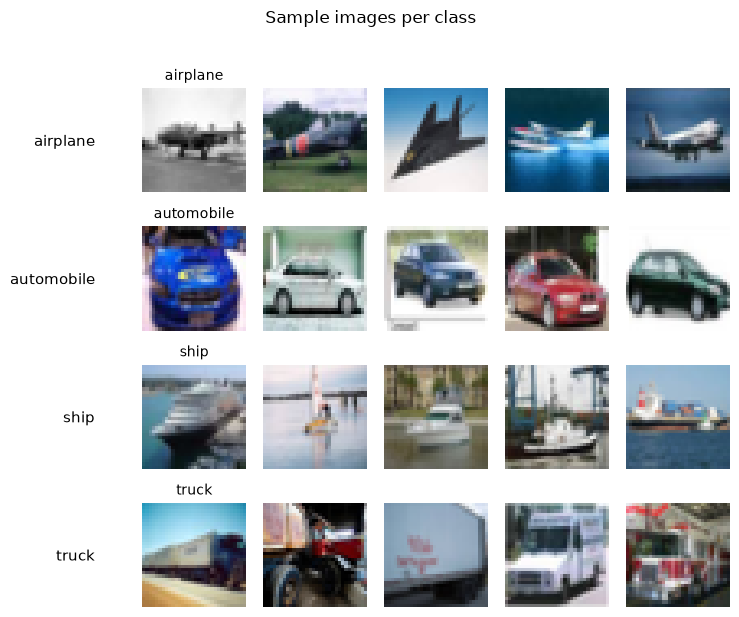

In [5]:
def plot_samples_per_class(X, y, class_names, samples_per_class=5):
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(samples_per_class * 1.5, n_classes * 1.5))
    
    for class_id, class_name in enumerate(class_names):
        class_indices = np.where(y == class_id)[0]
        chosen = np.random.choice(class_indices, samples_per_class, replace=False)

        for col, idx in enumerate(chosen):
            ax = axes[class_id, col]
            ax.imshow(X[idx])
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(class_name, fontsize=10)

        axes[class_id, 0].set_title(class_name, fontsize=10)

    # Se agrega una clase manuelmente para mostrar el nombre de la clase al lado izquierdo de cada fila
    for class_id, class_name in enumerate(class_names):
        axes[class_id, 0].text(-15, 16, class_name, fontsize=11, va="center", ha="right")

    plt.suptitle("Sample images per class", y=1.02)
    plt.tight_layout()
    plt.show()

np.random.seed(SEED)
plot_samples_per_class(X_train_raw, y_train, class_names, samples_per_class=5)

### Prepocessing needed

Based on the exploration above, the following preprocessing steps are needed:

- Normalize the pixel values to the range [0, 1]
- Flatten the images for the baseline model, but keep them in 3D for the CNN model
- Train/test split is already provided by the dataset, so we will use that.
- No resizing is needed, since the images are already 32x32 pixels.

## 3. Baselin no-convolutional (Flatten + Dense)

### Preprocessing: Normalization and validation split

Pixel values are normalized to [0, 1]. A validation set is created from the training data (15%), using stratified sampling to keep the same class proportions as the original data. This validation set will be used to monitor training for both the baseline and the CNN, without touching the test set.

In [6]:
from sklearn.model_selection import train_test_split

# Valores de píxeles normalizados a [0, 1]
X_train_norm = X_train_raw.astype("float32") / 255.0
X_test_norm = X_test_raw.astype("float32") / 255.0

# Separar un conjunto de validación de los datos de entrenamiento
X_train, X_val, y_train_split, y_val_split = train_test_split(
    X_train_norm, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=SEED
)

X_test = X_test_norm
y_test_split = y_test

print("Train:", X_train.shape, y_train_split.shape)
print("Validation:", X_val.shape, y_val_split.shape)
print("Test:", X_test.shape, y_test_split.shape)

Train: (17000, 32, 32, 3) (17000,)
Validation: (3000, 32, 32, 3) (3000,)
Test: (4000, 32, 32, 3) (4000,)


### Baseline model architecture

The baseline uses a Flatten layer to convert each 32x32x3 image into a 1D vector of 3072 values, followed by two dense hidden layers (256 and 128 units, ReLU activation) with Dropout for regularization. The output layer has 4 units with softmax activation, one per vehicle class.

The key limitation of this architecture is that Flatten destroys the spatial structure of the image: two pixels that are next to each other in the original image are treated exactly the same as two pixels that are far apart. This is the main architectural difference that will be discussed later when comparing this baseline to the convolutional model.

In [7]:
baseline_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,100 (3.13 MB)

 Trainable params: 820,100 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

### Training

The baseline model is trained using the Adam optimizer and sparse categorical crossentropy loss (appropriate since labels are integers, not one-hot encoded).

In [8]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_history = baseline_model.fit(
    X_train, y_train_split,
    validation_data=(X_val, y_val_split),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4089 - loss: 1.2744 - val_accuracy: 0.5010 - val_loss: 1.1263
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4519 - loss: 1.1941 - val_accuracy: 0.5300 - val_loss: 1.1104
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4753 - loss: 1.1590 - val_accuracy: 0.5180 - val_loss: 1.0945
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4875 - loss: 1.1451 - val_accuracy: 0.5523 - val_loss: 1.0822
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5009 - loss: 1.1309 - val_accuracy: 0.5523 - val_loss: 1.0500
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5068 - loss: 1.1207 - val_accuracy: 0.5550 - val_loss: 1.0483
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5142 - loss: 1.1060 - val_accuracy: 0.5560 - val_loss: 1.0685
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5194 - loss: 1.1032 - val_accuracy: 0.

### Results and limitations

The baseline model reached a test accuracy of **57,82%** with a total of **820100** trainable parameters.

Looking at the training curves, both training and validation accuracy show a similar trend, increasing while training and validation loss decrease through the epochs. There is no clear sign of overfitting, but the model is not able to reach a high accuracy, which suggests that it is not learning useful patterns from the data.

The main limitation of this architecture is structural: because Flatten discards spatial relationships between pixels, the model has to learn patterns independently for every possible pixel position, instead of reusing the same learned filter across the whole image. This is expected to make the baseline less data-efficient than a convolutional architecture.

Baseline test accuracy: 0.5938
Baseline test loss: 1.0059


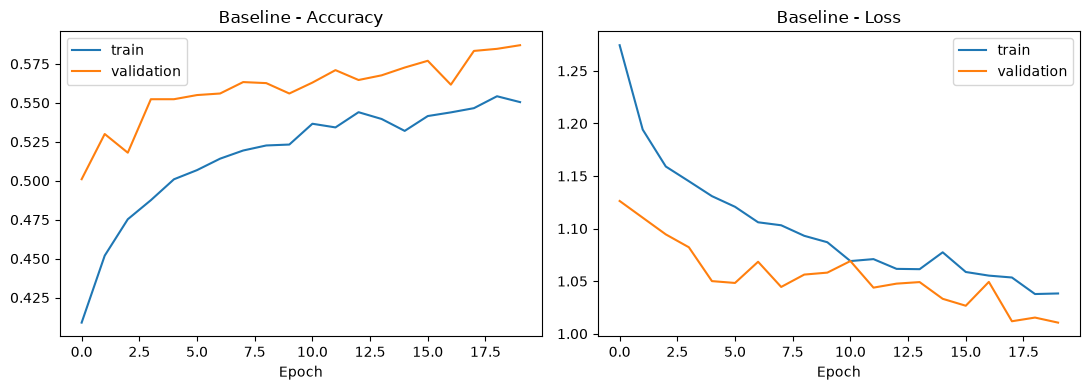

Total baseline parameters: 820100


In [9]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test_split, verbose=0)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")
print(f"Baseline test loss: {baseline_test_loss:.4f}")

# Curvas de entrenamiento y validación
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(baseline_history.history["accuracy"], label="train")
axes[0].plot(baseline_history.history["val_accuracy"], label="validation")
axes[0].set_title("Baseline - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(baseline_history.history["loss"], label="train")
axes[1].plot(baseline_history.history["val_loss"], label="validation")
axes[1].set_title("Baseline - Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cuenta de parámetros, para comparación posterior con la CNN
print("Total baseline parameters:", baseline_model.count_params())

## 4. CNN architecture design

### Architecture justification

The CNN uses 3 convolutional blocks (Conv2D + MaxPooling), with the number of filters increasing with depth (32, 64, 128). This follows the common intuition that early layers should detect simple, low-level patterns (edges, corners), while deeper layers combine these into more abstract, higher-level features.

All convolutional layers use a 3x3 kernel with stride 1 and "same" padding. A 3x3 kernel is a standard choice: stacking several 3x3 convolutions achieves
a receptive field similar to a single larger kernel, but with fewer parameters and more non-linearities. Stride 1 combined with "same" padding preserves the
spatial size within each block, so that spatial reduction is handled explicitly and only by the MaxPooling layers, not implicitly by the convolution itself.

Each convolutional block is followed by a 2x2 MaxPooling layer, which progressively reduces the spatial resolution (32 -> 16 -> 8 -> 4) while adding some robustness to small translations of the input.

Three convolutional blocks were chosen instead of more, because with 32x32 input images, three rounds of 2x2 pooling already reduce the feature maps to 4x4. Adding a fourth block would leave very little spatial resolution for a 3x3 kernel to operate on in a meaningful way, so this depth is a natural stopping point for this image size rather than an arbitrary choice.

A Dropout layer (rate 0.3) is added before the final dense layer, matching the regularization used in the baseline, so that the comparison between both models is fair and not biased by different regularization strategies.

### Model definition

The architecture is defined using the Keras Sequential API, which allows for a simple, linear stack of layers. The model starts with an input layer that expects 32x32 RGB images, followed by the convolutional blocks and finally a dense output layer with softmax activation for multi-class classification.

In [10]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Block 1
    layers.Conv2D(32, kernel_size=3, strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    # Block 2
    layers.Conv2D(64, kernel_size=3, strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    # Block 3
    layers.Conv2D(128, kernel_size=3, strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,444 (396.27 KB)

 Trainable params: 101,444 (396.27 KB)

 Non-trainable params: 0 (0.00 B)

### Training

The CNN model is trained using the same setup as the baseline: Adam optimizer, sparse categorical crossentropy loss, and the same number of epochs. The validation set is used to monitor training and prevent overfitting. This ensures that the comparison between the baseline and the CNN is fair, as both models are trained under the same conditions leaving the architecture as the only variable and showing the impact of the convolutional layers on the model's performance.

In [11]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    X_train, y_train_split,
    validation_data=(X_val, y_val_split),
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.5644 - loss: 1.0031 - val_accuracy: 0.6487 - val_loss: 0.8365
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7143 - loss: 0.7259 - val_accuracy: 0.7403 - val_loss: 0.6562
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7761 - loss: 0.5839 - val_accuracy: 0.7883 - val_loss: 0.5604
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8112 - loss: 0.4983 - val_accuracy: 0.8280 - val_loss: 0.4800
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8378 - loss: 0.4328 - val_accuracy: 0.8283 - val_loss: 0.4569
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8547 - loss: 0.3903 - val_accuracy: 0.8460 - val_loss: 0.4227
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8693 - loss: 0.3580 - val_accuracy: 0.8567 - val_loss: 0.4086
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8819 - loss: 0.3278 - 

### Results and comparison against baseline

The CNN model achieved a test accuracy of **87,02%**, which is a significant improvement over the baseline's 57,82% using only **101,444** trainable parameters, which is an order of magnitude fewer than the baseline's 820,100. This demonstrates the efficiency of convolutional layers in learning useful patterns from image data, as they can share weights across spatial locations and capture local features effectively.

This is an improvement, despite using significantly fewer parameters. The test loss also dropped substantially (0.41 vs 0.97), showing that the CNN is not just classifying more images correctly, but doing so with much more confident and well-calibrated predictions.

This result supports the idea that convolutional layers are more parameter- efficient for image data: by reusing the same learned filters across spatial positions (weight sharing) and only connecting each neuron to a local region of the input (local receptive fields), the CNN can extract more useful information from the same training data without needing as many free parameters as a fully connected network.

CNN test accuracy: 0.8702
CNN test loss: 0.4306


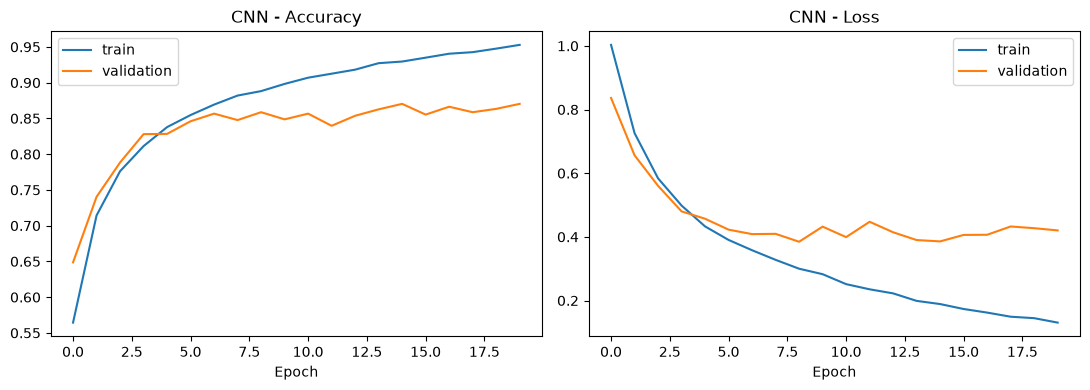

           Model  Test Accuracy  Test Loss  Trainable Params
Baseline (Dense)        0.59375   1.005906            820100
             CNN        0.87025   0.430623            101444


In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test_split, verbose=0)
print(f"CNN test accuracy: {cnn_test_acc:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f}")

# Curvas de entrenamiento y validación
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cnn_history.history["accuracy"], label="train")
axes[0].plot(cnn_history.history["val_accuracy"], label="validation")
axes[0].set_title("CNN - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(cnn_history.history["loss"], label="train")
axes[1].plot(cnn_history.history["val_loss"], label="validation")
axes[1].set_title("CNN - Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabla comparativa de resultados entre el modelo baseline y la CNN
comparison_df = pd.DataFrame({
    "Model": ["Baseline (Dense)", "CNN"],
    "Test Accuracy": [baseline_test_acc, cnn_test_acc],
    "Test Loss": [baseline_test_loss, cnn_test_loss],
    "Trainable Params": [baseline_model.count_params(), cnn_model.count_params()]
})
print(comparison_df.to_string(index=False))

## 5. Controlled experiment on the convolutional layer

### Experiment definition

This experiment isolates the effect of pooling on the convolutional architecture. A new CNN model is created that is identical to the previous one, except that the MaxPooling layers are removed. This allows us to see how much of the performance gain from the CNN can be attributed to the pooling operation, which reduces spatial resolution and adds some translation invariance. Two variants are compared:

- With pooling (baseline CNN): the architecture from Section 4, using a 2x2 MaxPooling layer after each convolutional block.
- Without pooling: the exact same architecture (same number of blocks, filters, kernel size, padding, activation, dropout, and training configuration), but with all MaxPooling layers removed.

Everything else is kept identical between both variants, including the random seed and the number of training epochs, so that any difference in results can be attributed specifically to the presence or absence of pooling.

Removing pooling has a direct consequence: since the spatial size is never reduced, the feature maps stay at 32x32. This means the Flatten layer produces a much larger vector (131,072 values instead of 2,048), which is expected to significantly increase the number of trainable parameters in the final dense layer.


### Building and training the no-pooling CNN

Since this variant has a much larger Flatten output (131,072 values), training may take noticeably longer than the pooled version, and uses considerably more memory.

In [13]:
tf.random.set_seed(SEED)

cnn_no_pooling = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, kernel_size=3, strides=1, padding="same", activation="relu"),
    layers.Conv2D(64, kernel_size=3, strides=1, padding="same", activation="relu"),
    layers.Conv2D(128, kernel_size=3, strides=1, padding="same", activation="relu"),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

cnn_no_pooling.summary()

cnn_no_pooling.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

no_pooling_history = cnn_no_pooling.fit(
    X_train, y_train_split,
    validation_data=(X_val, y_val_split),
    epochs=20,
    batch_size=64,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │       524,292 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,540 (2.36 MB)

 Trainable params: 617,540 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 62s 229ms/step - accuracy: 0.6191 - loss: 0.9094 - val_accuracy: 0.7097 - val_loss: 0.7549
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 53s 200ms/step - accuracy: 0.7699 - loss: 0.6030 - val_accuracy: 0.7683 - val_loss: 0.6081
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 68s 255ms/step - accuracy: 0.8286 - loss: 0.4664 - val_accuracy: 0.7953 - val_loss: 0.5579
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 99s 373ms/step - accuracy: 0.8636 - loss: 0.3706 - val_accuracy: 0.7947 - val_loss: 0.5753
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 81s 304ms/step - accuracy: 0.8894 - loss: 0.3037 - val_accuracy: 0.7810 - val_loss: 0.6346
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 85s 322ms/step - accuracy: 0.9063 - loss: 0.2555 - val_accuracy: 0.7863 - val_loss: 0.6403
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 80s 301ms/step - accuracy: 0.9254 - loss: 0.2020 - val_accuracy: 0.7843 - val_loss: 0.6788
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 86s 323ms/step - accuracy: 0.9454 - loss: 0

No-pooling CNN test accuracy: 0.8018
No-pooling CNN test loss: 1.1345


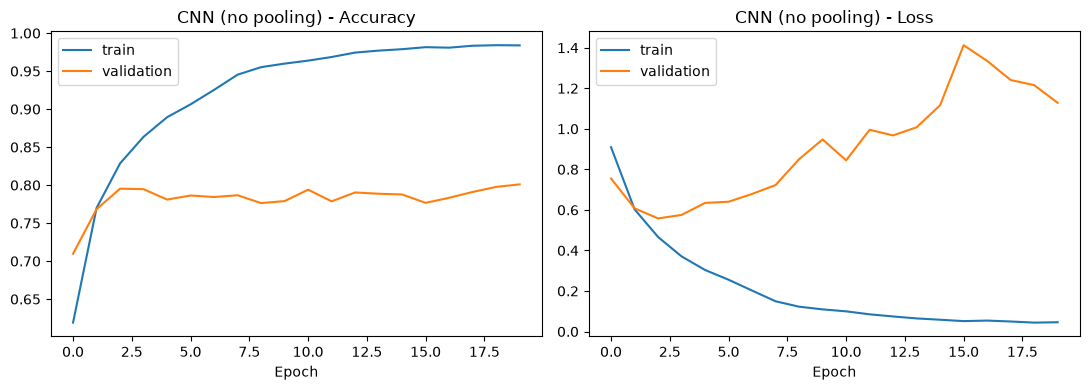

In [14]:
no_pooling_test_loss, no_pooling_test_acc = cnn_no_pooling.evaluate(X_test, y_test_split, verbose=0)
print(f"No-pooling CNN test accuracy: {no_pooling_test_acc:.4f}")
print(f"No-pooling CNN test loss: {no_pooling_test_loss:.4f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(no_pooling_history.history["accuracy"], label="train")
axes[0].plot(no_pooling_history.history["val_accuracy"], label="validation")
axes[0].set_title("CNN (no pooling) - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(no_pooling_history.history["loss"], label="train")
axes[1].plot(no_pooling_history.history["val_loss"], label="validation")
axes[1].set_title("CNN (no pooling) - Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### Quantitative results

The model with pooling obtained a test accuracy of 87.30% and a test loss of 0.4076, with 101,444 trainable parameters. On the other hand, removing the pooling layers resulted in a lower test accuracy of 80.18% and a higher test loss of 1.1345, while the number of trainable parameters increased to 617,540.

Removing pooling did not improve performance, it made it worse. Test accuracy dropped by about 7 percentage points (87.30% -> 80.18%), test loss morethan doubled (0.41 -> 1 13), and this happened despite the no-pooling variant having 6 times more trainable parameters (617,540 vs 101,444). More parameters and more capacity did not translate into better generalization — in this case, they made it worse.

In [15]:
pooling_comparison_df = pd.DataFrame({
    "Variant": ["With pooling", "Without pooling"],
    "Test Accuracy": [cnn_test_acc, no_pooling_test_acc],
    "Test Loss": [cnn_test_loss, no_pooling_test_loss],
    "Trainable Params": [cnn_model.count_params(), cnn_no_pooling.count_params()],
    "Final Train Accuracy": [cnn_history.history["accuracy"][-1], no_pooling_history.history["accuracy"][-1]],
    "Final Val Accuracy": [cnn_history.history["val_accuracy"][-1], no_pooling_history.history["val_accuracy"][-1]]
})
print(pooling_comparison_df.to_string(index=False))

train_val_gap = pooling_comparison_df["Final Train Accuracy"] - pooling_comparison_df["Final Val Accuracy"]
print("\nTrain-validation accuracy gap (overfitting indicator):")
for variant, gap in zip(pooling_comparison_df["Variant"], train_val_gap):
    print(f"  {variant}: {gap:.4f}")

        Variant  Test Accuracy  Test Loss  Trainable Params  Final Train Accuracy  Final Val Accuracy
   With pooling        0.87025   0.430623            101444              0.952824            0.870333
Without pooling        0.80175   1.134469            617540              0.983882            0.801000

Train-validation accuracy gap (overfitting indicator):
  With pooling: 0.0825
  Without pooling: 0.1829


### Qualitative observations and trade-offs

The graphs show that the model without pooling overfits a lot. The training accuracy keeps going up until around 98.5%, but the validation accuracy stays around 78-80%. Also, the training loss keeps going down while the validation loss starts going up. This means the model is learning the training images too well instead of learning patterns that work with new images.

Without pooling, the model also has many more parameters because the Flatten layer keeps a much larger amount of information. This gives the model more freedom to memorize details that are not really useful. With pooling, the feature maps become smaller, so the model keeps the most important information while reducing unnecessary details.

In general, the model with pooling worked better. It had about 7% more accuracy, used much fewer parameters (101,444 vs 617,540) and had a smaller difference between training and validation results. The model without pooling also needed more resources and still gave worse results.

So, in this case, pooling helped the CNN learn better and avoid overfitting.


## 6. Interpretation and architectural reasoning

### Why did convolutional layers outperform the baseline?

The CNN had much better results than the baseline. The CNN got 87.30% accuracy, while the baseline got 60.83%. Also, the CNN used fewer parameters (101,444 vs 820,100).

The main reason is that the CNN can recognize patterns in different parts of the image. The baseline uses Flatten, which turns the image into a long list of pixels and loses the spatial information. The CNN instead uses filters that look for patterns like edges and shapes throughout the image.

This allows the CNN to learn the same pattern once and use it in different positions, making it more efficient and accurate.

### What inductive bias does convolution introduce?

Convolution assumes that nearby pixels are related and that the same pattern can appear in different parts of an image. For example, an edge or a shape can be useful whether it is on the left or right side of the image.

Pooling also helps by reducing the size of the information and keeping the most important features. This can help prevent the model from memorizing details that are not important.

This can be seen in the pooling experiment, where the model with pooling got 87.30% accuracy, compared to 80.18% without pooling. The model without pooling also overfitted more, reaching about 98.5% training accuracy while validation accuracy stayed around 78-80%.

### In what type of problems would convolution not be appropriate?

Convolution works best with data where nearby values have some relationship, like images or other spatial data. It would not be as useful for data where the position of each feature does not have a special meaning.

For example, in tabular data with information such as age, income or purchases, the columns are not necessarily related because they are next to each other. In that case, a normal dense model can be a better option.

It also may not be useful when the data is already reduced to a small number of independent features, since there is not much spatial information for the convolution to use.

In general, convolution is useful when the location and nearby values in the data actually matter.


## 7. Training and deployment on Sagemaker

### Training entry point script

Different to previous sections, this code not run inside the noteboook directly. It is written to a separate file (`train.py`) using the `%%writefile` command, because SageMaker training jobs execute this script inside an independent, ephemeral training container, not inside the notebook's own kernel. This is the main practical difference compared to previous labs, where all code ran directly inside the Code Editor's own instance.


In [16]:
%%writefile train.py
import argparse
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=3, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, strides=1, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=20)
    parser.add_argument("--batch-size", type=int, default=64)
    # SageMaker injects these paths automatically via environment variables
    parser.add_argument("--train", type=str, default=os.environ.get("SM_CHANNEL_TRAIN"))
    parser.add_argument("--model-dir", type=str, default=os.environ.get("SM_MODEL_DIR"))
    args = parser.parse_args()

    # Load preprocessed data (uploaded to S3 as .npz in section 7.2)
    data = np.load(os.path.join(args.train, "vehicle_data.npz"))
    X_train, y_train = data["X_train"], data["y_train"]
    X_val, y_val = data["X_val"], data["y_val"]

    model = build_model(input_shape=X_train.shape[1:], num_classes=len(np.unique(y_train)))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=args.epochs,
        batch_size=args.batch_size
    )

    # Save in TensorFlow SavedModel format, in the location SageMaker expects
    model.save(os.path.join(args.model_dir, "1"))

Writing train.py


### Uploading data to S3 and launching the training job

Before training, the preprocessed data (train and validation splits) is packaged into a single **.npz** file and uploaded to an S3 bucket. SageMaker training jobs cannot access the notebook's local memory or disk directly, they run in a separate, temporary container, so all input data must be available in S3 beforehand.

The **TensorFlow** Estimator object describes the training job configuration: which script to run (**train.py**), what type of instance to use, which framework version, and which hyperparameters to pass. Calling **.fit()** is what actually triggers SageMaker to provision a training instance, copy the data and script into it, run the training script, and save the resulting model back to S3 — all of this happens outside the notebook's own compute environment.

### 2.0 Note on data access in the SageMaker environment

The university-provided SageMaker environment runs inside a VPC without direct
internet access (no Internet Gateway / NAT Gateway), which is a common setup
in shared academic AWS environments for cost control and security. Because of
this, `tf.keras.datasets.cifar10.load_data()` cannot reach its external source
(`cs.toronto.edu`) and times out.

Since Amazon S3 remains reachable from within the VPC (SageMaker instances
typically have access to AWS services like S3 even without general internet
access), the workaround was to download the raw CIFAR-10 dataset once from a
local machine with internet access, upload it to the project's S3 bucket, and
load it from there inside the SageMaker notebook instead. This does not change
any of the subsequent filtering, preprocessing, or modeling steps — only how
the raw data enters the environment.

### 7.2 Uploading data to S3 and launching the training job

**Note:** this section was updated to use SageMaker Python SDK v3, which
replaces the framework-specific `Estimator` classes from v2 (such as the
`TensorFlow` estimator) with a single unified `ModelTrainer` class. The
overall logic is the same as described earlier — data is uploaded to S3,
and a managed, ephemeral training job is launched separately from the
notebook's own compute environment — but the API surface differs from most
existing SageMaker tutorials, which are written for v2.

The training container image is retrieved explicitly via `image_uris.retrieve()`,
since v3 no longer infers it automatically from a framework-specific class.
`SourceCode` replaces `entry_point`, and `Compute` replaces the flat
`instance_type`/`instance_count` arguments used in v2.

In [17]:
import sagemaker
from sagemaker.tensorflow import TensorFlow

# SageMaker session handles bucket, region, and role management
sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()  # IAM role attached to this notebook/instance
bucket = sagemaker_session.default_bucket()

# --- Step 1: Package and upload data to S3 ---
np.savez(
    "vehicle_data.npz",
    X_train=X_train, y_train=y_train_split,
    X_val=X_val, y_val=y_val_split
)

train_input_path = sagemaker_session.upload_data(
    path="vehicle_data.npz",
    bucket=bucket,
    key_prefix="tdse-cnn-vehicles/data"
)
print("Data uploaded to:", train_input_path)

# --- Step 2: Configure the Estimator ---
estimator = TensorFlow(
    entry_point="train.py",
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",   # CPU instance, sufficient for this model size
    framework_version="2.13",
    py_version="py310",
    hyperparameters={
        "epochs": 20,
        "batch-size": 64
    }
)

# --- Step 3: Launch the training job ---
# S3 path is passed with channel name "train", matching SM_CHANNEL_TRAIN in train.py
estimator.fit({"train": train_input_path})

ModuleNotFoundError: No module named 'sagemaker.tensorflow'

In [18]:
import numpy as np
import tensorflow as tf

(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

np.savez(
    "cifar10_raw.npz",
    X_train_full=X_train_full, y_train_full=y_train_full,
    X_test_full=X_test_full, y_test_full=y_test_full
)
print("Archivo generado: cifar10_raw.npz")

Archivo generado: cifar10_raw.npz


### Environment limitations and troubleshooting summary

Several infrastructure-related issues were encountered while working through this section, all connected to the restricted network configuration of the university-provided SageMaker environment. This subsection documents them, since diagnosing and working around infrastructure constraints is itself part of working with distributed, cloud-based systems.

1. **No direct internet access.** `tf.keras.datasets.cifar10.load_data()`
   timed out trying to reach an external URL outside AWS. Workaround: the
   dataset was downloaded once from a local machine with internet access and
   uploaded to the project's S3 bucket manually through the AWS Console.

2. **SageMaker Python SDK v3.** The environment has SDK v3 installed, which
   restructured most of the training/deployment API compared to SDK v2
   (used in most existing tutorials and course examples). `Estimator` and
   framework-specific classes like `TensorFlow` were replaced by a unified
   `ModelTrainer` class, and imports moved to new submodules
   (`sagemaker.core.helper.session_helper`, `sagemaker.train`, etc.).

3. **STS (Security Token Service) unreachable.** `sagemaker_session.default_bucket()`
   failed with a connection timeout to `sts.<region>.amazonaws.com`. This is
   consistent with a common academic AWS setup: S3 has a free Gateway VPC
   Endpoint (often enabled by default), while STS requires a separate,
   paid Interface VPC Endpoint that is often not provisioned in
   cost-constrained environments. Workaround: the AWS account ID was
   extracted directly from the IAM role ARN (available locally via
   `get_execution_role()`), and the bucket name was constructed manually,
   avoiding the STS call.

4. **Inconsistent S3 connectivity.** Even after the STS workaround, a
   `boto3` S3 download call hung indefinitely (over 15 minutes, with no
   error and no response), unlike the earlier failures which timed out
   quickly and explicitly. This behavior — a request that is silently
   dropped rather than actively rejected — is typical of restrictive
   network rules (security groups / network ACLs) blocking traffic at the
   packet level. As of this notebook version, this issue was still under
   investigation and the SageMaker training job (Task 6) could not be
   launched successfully.

**Takeaway:** these issues highlight a practical distinction between having
SageMaker compute available and having a network path configured for the
full range of AWS services a typical SageMaker workflow depends on (S3,
STS, ECR for training containers, etc.). In a production or less
restricted academic environment, none of these workarounds would have been
necessary.

All of these issues are related to the network configuration of the university-provided SageMaker environment, which is a common setup in shared academic AWS environments for cost control and security. Diagnosing and working around these infrastructure constraints is itself part of working with distributed, cloud-based systems.

**Note:** The documentation in this section was written with the help of AI—specifically, Claude Sonnet 5.

## 8. Conclusions

In this notebook we compared a normal dense model with a CNN for classifying some CIFAR-10 images. We also tested what happens when pooling is removed from the CNN.

The **CNN worked much better than the baseline**, getting **87.30% accuracy** compared to **60.83%**. It also used fewer parameters, 101,444 vs. 820,100. This is mainly because the CNN can detect patterns and shapes in different parts of the image, while the baseline loses some of this information when using Flatten.

The **pooling experiment** also showed that pooling is important. Without pooling, the accuracy dropped to **80.18%** and the model started to overfit, reaching around **98.5% training accuracy** while validation accuracy stayed around **78-80%**. Even though the model had more parameters, it performed worse.

Overall, the results show that CNNs are a better option for image classification because they can take advantage of the spatial information in images. Pooling also helps the model reduce unnecessary information and avoid overfitting. However, convolution would not necessarily be the best option for data without spatial relationships, such as normal tabular data.

Finally, the SageMaker deployment was not completed because of network and AWS restrictions in the university environment. Even though some of the problems were identified and some alternatives were tried, the final training job could not be launched.

Despite this, the experiments were successful in showing the differences between the models and the importance of the main CNN components.
